Enter the total path length for road construction (in meters):  100
Enter the drone altitude (in meters):  60


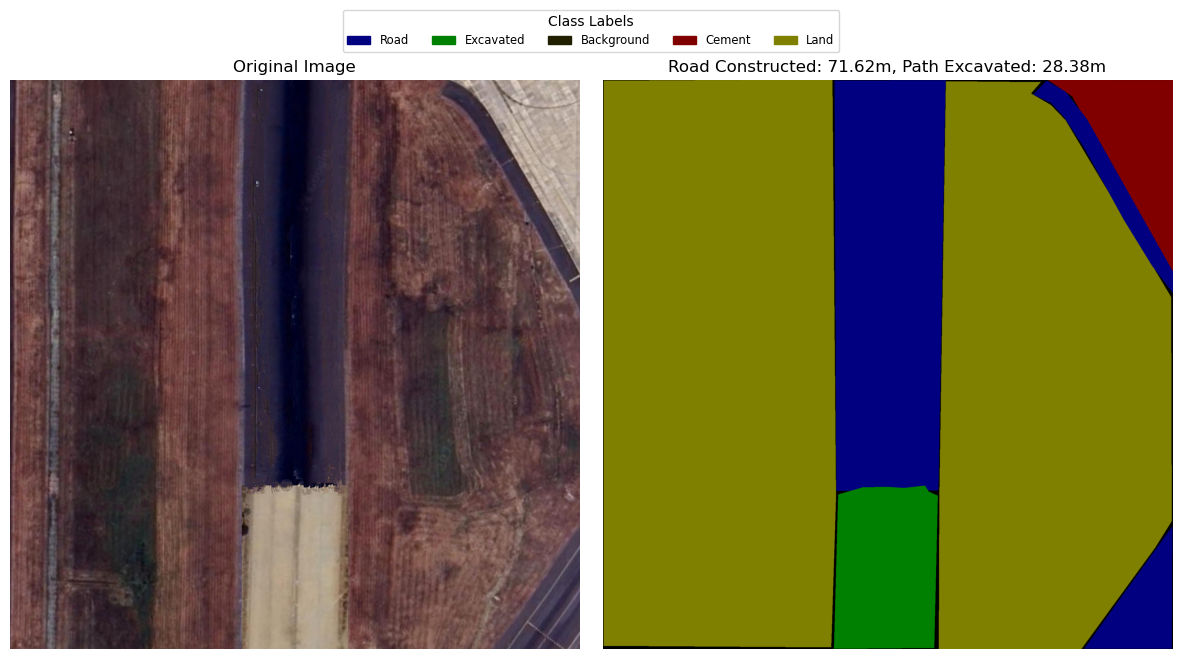

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

def load_image(image_path):
    """
    Load an image from a file path.
    Args:
        image_path (str): Path to the segmented image file.
    Returns:
        numpy array: Loaded image.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image could not be loaded. Check the file path.")
    return image

def calculate_longest_path(image, class_color):
    """
    Calculate the longest connected consecutive pixels for a specific class.
    Args:
        image (numpy array): Input segmented image.
        class_color (tuple): RGB color of the class to measure.
    Returns:
        int: Longest path in pixels (horizontal or vertical).
    """
    # Convert the image to RGB format
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Create a mask for the specified class
    mask = np.all(image_rgb == class_color, axis=-1).astype(np.uint8)
    
    # Find the longest line of connected pixels in both directions
    horizontal_length = max([np.sum(row) for row in mask])
    vertical_length = max([np.sum(col) for col in mask.T])
    
    # Return the longer of the two
    return max(horizontal_length, vertical_length)

def compute_road_status(image, road_color, excavated_color, total_path_length, drone_altitude):
    """
    Compute the constructed road and excavated lengths within the total path length.
    Args:
        image (numpy array): Input segmented image.
        road_color (tuple): RGB color for the "Road" class.
        excavated_color (tuple): RGB color for the "Excavated" class.
        total_path_length (float): Total path length in meters for road construction.
        drone_altitude (float): Drone altitude in meters.
    Returns:
        dict: Dictionary containing constructed road and excavated lengths.
    """
    # Calculate pixel size (meters per pixel)
    pixel_size = drone_altitude / image.shape[0]
    
    # Compute the longest paths for Road and Excavated classes
    road_length_pixels = calculate_longest_path(image, road_color)
    excavated_length_pixels = calculate_longest_path(image, excavated_color)
    
    # Convert pixel lengths to real-world lengths
    road_length_meters = road_length_pixels * pixel_size
    excavated_length_meters = excavated_length_pixels * pixel_size
    
    # Scale road and excavated lengths to match total path length
    total_calculated_length = road_length_meters + excavated_length_meters
    if total_calculated_length > 0:
        scale_factor = total_path_length / total_calculated_length
        road_length_meters *= scale_factor
        excavated_length_meters *= scale_factor
    
    return {
        "constructed_road_length": road_length_meters,
        "excavated_length": excavated_length_meters
    }

# Define class colors
class_colors = {
    "Road": (27, 122, 0),
    "Excavated": (162, 115, 83),
    "Background": (0, 0, 0),
    "Cement": (176, 176, 176),
    "Land": (110, 67, 38),
}

# User Inputs
image_path = 'label.png'
original_image_path = 'img.png'
total_path_length = float(input("Enter the total path length for road construction (in meters): "))
drone_altitude = float(input("Enter the drone altitude (in meters): "))

# Load images
segmented_image = load_image(image_path)
original_image = plt.imread(original_image_path)

# Compute road status
road_status = compute_road_status(segmented_image, class_colors["Road"], class_colors["Excavated"], total_path_length, drone_altitude)

# Create legend handles
legend_handles = [
    Patch(color=np.array(color) / 255, label=label) for label, color in class_colors.items()
]

# Plot side-by-side images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original Image
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Segmented Image
axes[1].imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Road Constructed: {road_status['constructed_road_length']:.2f}m, Path Excavated: {road_status['excavated_length']:.2f}m")
axes[1].axis('off')

# Add legend
fig.legend(handles=legend_handles, loc='upper center', ncol=5, fontsize='small', title="Class Labels", bbox_to_anchor=(0.5, 1.10))

plt.tight_layout()
plt.show()

In [1]:
import os
import subprocess

# Input and output directories
input_dir = "labelme_annotations"  # Folder containing the JSON files
output_dir = "segmentation_data"   # Folder to store the processed data

# Create output subdirectories
masks_dir = os.path.join(output_dir, "masks")
visualizations_dir = os.path.join(output_dir, "visualizations")
images_dir = os.path.join(output_dir, "images")
os.makedirs(masks_dir, exist_ok=True)
os.makedirs(visualizations_dir, exist_ok=True)
os.makedirs(images_dir, exist_ok=True)

# Set to store unique labels
label_set = set()

# Process each JSON file
for json_file in os.listdir(input_dir):
    if json_file.endswith(".json"):
        json_path = os.path.join(input_dir, json_file)
        dataset_path = os.path.join(output_dir, os.path.splitext(json_file)[0])

        # Run labelme_json_to_dataset
        subprocess.run(["labelme_json_to_dataset", json_path, "-o", dataset_path])

        # Move files to respective folders
        os.rename(
            os.path.join(dataset_path, "label.png"),
            os.path.join(masks_dir, os.path.splitext(json_file)[0] + ".png")
        )
        os.rename(
            os.path.join(dataset_path, "img.png"),
            os.path.join(images_dir, os.path.splitext(json_file)[0] + ".png")
        )
        os.rename(
            os.path.join(dataset_path, "visualization.png"),
            os.path.join(visualizations_dir, os.path.splitext(json_file)[0] + ".png")
        )

        # Update label set from label_names.txt
        label_file = os.path.join(dataset_path, "label_names.txt")
        if os.path.exists(label_file):
            with open(label_file, "r") as f:
                labels = f.read().splitlines()
                label_set.update(labels)

# Write consolidated label_names.txt
consolidated_labels_path = os.path.join(output_dir, "label_names.txt")
with open(consolidated_labels_path, "w") as f:
    f.write("\n".join(sorted(label_set)))

print("Segregation complete! Consolidated labels written to:", consolidated_labels_path)

FileNotFoundError: [WinError 2] The system cannot find the file specified